<a href="https://colab.research.google.com/github/GutoCaetano98/Uninter/blob/main/Pratica_FakeNews_NLP_RU4313007_Jos%C3%A9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTAÇÕES
import pandas as pd
import numpy as np
import nltk
import re
import matplotlib.pyplot as plt

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

from wordcloud import WordCloud

# IDENTIFICADOR PESSOAL (OBRIGATÓRIO)
contador4313007 = 1

In [2]:
# DOWNLOAD NLTK
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# IDENTIFICADOR PESSOAL (OBRIGATÓRIO)
contador4313007 = 1

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# UPLOAD DO DATASET
from google.colab import files
uploaded = files.upload()

Saving pre-processed.csv to pre-processed (2).csv


In [4]:
# LEITURA DO DATASET
df = pd.read_csv("pre-processed.csv", encoding='utf-8')

# IDENTIFICADOR PESSOAL (OBRIGATÓRIO)
contador4313007 = 1

In [5]:
# VERIFICAR COLUNAS
print(df.head())
print(df.columns)
print(df['label'].value_counts())

   index label                                  preprocessed_news
0      0  fake  katia abreu diz vai colocar expulsao moldura n...
1      1  fake  ray peita bolsonaro conservador fake entrevist...
2      2  fake  reinaldo azevedo desmascarado policia federal ...
3      3  fake  relatorio assustador bndes mostra dinheiro pub...
4      4  fake  radialista americano fala sobre pt vendem ilus...
Index(['index', 'label', 'preprocessed_news'], dtype='object')
label
fake    3600
true    3600
Name: count, dtype: int64


In [6]:
# PADRONIZAÇÃO
df['label'] = df['label'].replace({
    'fake': 'FAKE',
    'true': 'REAL'
})

In [7]:
# USO DO NLTK
tokens = word_tokenize(df['preprocessed_news'][0])
print(tokens[:10])

['katia', 'abreu', 'diz', 'vai', 'colocar', 'expulsao', 'moldura', 'nao', 'reclamar', 'senadora']


In [8]:
# DFEINIÇÃO
X = df['preprocessed_news']
y = df['label']

# IDENTIFICADOR PESSOAL (OBRIGATÓRIO)
contador4313007 = 1

In [9]:
# TESTE
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print("Acurácia do modelo:", accuracy)

Acurácia do modelo: 0.8661111111111112


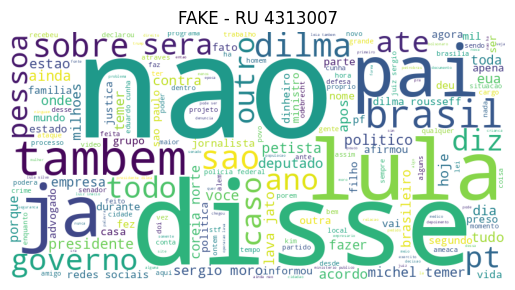

In [27]:
# FILTRAR SOMENTE FAKE
df_fake = df[df['label'] == 'FAKE']

fake_text = " ".join(df_fake['preprocessed_news'])

wc_fake = WordCloud(width=800, height=400, background_color='white').generate(fake_text)

plt.imshow(wc_fake)
plt.axis("off")
plt.title("FAKE - RU 4313007")
plt.show()

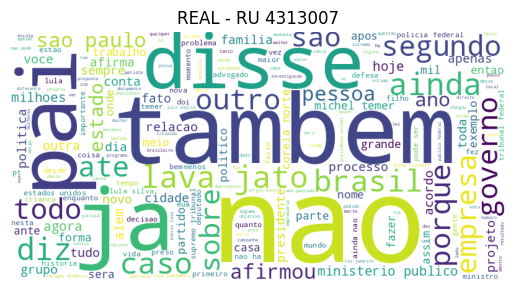

In [26]:
# FILTRAR SOMENTE REAL
df_real = df[df['label'] == 'REAL']

real_text = " ".join(df_real['preprocessed_news'])

wc_real = WordCloud(width=800, height=400, background_color='white').generate(real_text)

plt.imshow(wc_real)
plt.axis("off")
plt.title("REAL - RU 4313007")
plt.show()

In [28]:
# IDENTIFICADOR PESSOAL (OBRIGATÓRIO)
contador4313007 = 1

feature_names = vectorizer.get_feature_names_out()

unigramas = [f for f in feature_names if len(f.split()) == 1]
bigramas = [f for f in feature_names if len(f.split()) == 2]
trigramas = [f for f in feature_names if len(f.split()) == 3]

print("Quantidade de palavras (unigramas):", len(unigramas))
print("Quantidade de bigramas:", len(bigramas))
print("Quantidade de trigramas:", len(trigramas))

print("Acurácia do modelo:", accuracy)

Quantidade de palavras (unigramas): 4246
Quantidade de bigramas: 754
Quantidade de trigramas: 0
Acurácia do modelo: 0.8661111111111112
